# Statistic of simulated data

TODO: write git version of last functional run!

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# PlatoSim libraries
import platosim.utilities as ut
from platosim.slurm        import workerOverview
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## Overview of VSC resources 

In [3]:
# path = '/STER/platodata/PLATOSIM/simulations_PLATO-PL-DLR-TN-0108'
path = '/lhome/nicholas/software/workdir/DLR108'
paramFileNCAM = f'{path}/slurm/cluster_ncam.data'
paramFileFCAM = f'{path}/slurm/cluster_fcam.data'

### *N-CAMs*

<IPython.core.display.Javascript object>


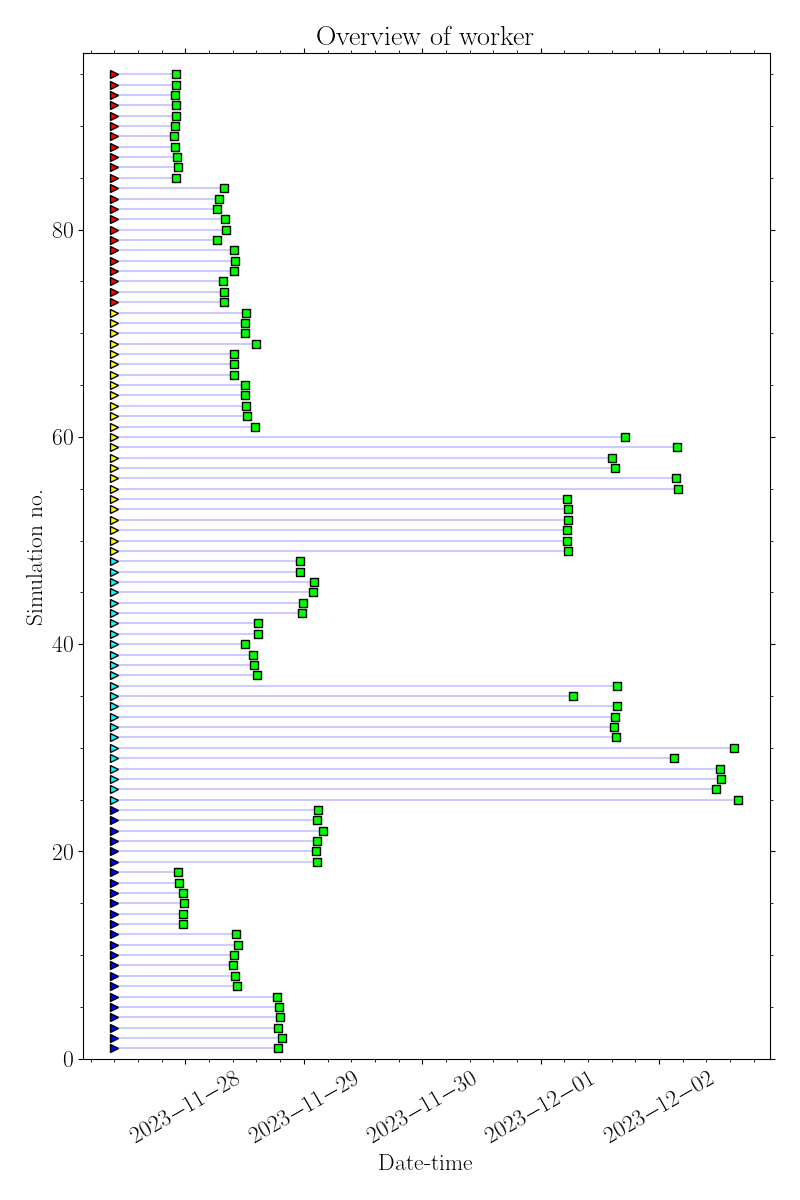

100%|██████████████████████████████████████████████████| 96/96 [00:00<00:00, 449

All simulations finished successfully!
Average walltime per cpu  : 2716.389 h
Fastest walltime for cpus : 719.383 h
Slowest walltime for cpus : 7588.633 h


In [23]:
workerLog = f'{path}/slurm/slurmNCAM_sim1/run.slurm.log55369051'
df, wt = workerOverview(workerLog, paramFileNCAM, ofile=False, plot=True, fullFrame=True)

In [40]:
# Generate new param files to more optimized batch simulations (a, b, c)
dexA = np.where(wt/86400 < 1)[0]
dexB = np.where((wt/86400 >= 1) & (wt/86400 <= 2))[0]
dexC = np.where(wt/86400 > 2)[0]

df = pd.read_csv(paramFileNCAM)
da = df.loc[dexA]
db = df.loc[dexB]
dc = df.loc[dexC]

da.reset_index(drop=True)
db.reset_index(drop=True)
dc.reset_index(drop=True)

da.to_csv(f'{path}/slurm/cluster_ncam_a.txt', index=False)
db.to_csv(f'{path}/slurm/cluster_ncam_b.txt', index=False)
dc.to_csv(f'{path}/slurm/cluster_ncam_c.txt', index=False)

In [42]:
# Number of cores to be used per batch
len(dexA), len(dexB), len(dexC)

(27, 45, 24)

### *F-CAMs*

<IPython.core.display.Javascript object>


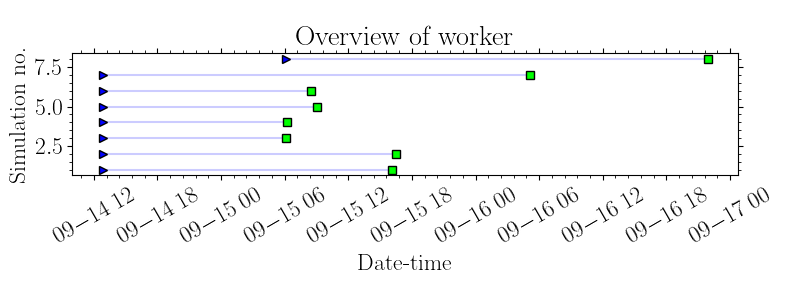

All simulations finished successfully!


In [13]:
# Blue filter
workerLog = f'{path}/slurm/slurmFCAM_sim0/worker.pbs.log55215879'
workerOverview(workerLog, paramFile, ofile=False, plot=True)

<IPython.core.display.Javascript object>


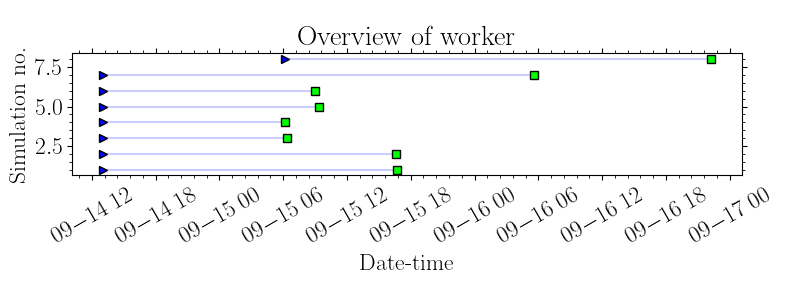

All simulations finished successfully!


In [14]:
# Red filter
workerLog = f'{path}/slurm/slurmFCAM_sim1/worker.pbs.log55215884'
workerOverview(workerLog, paramFile, ofile=False, plot=True)